In [1]:
# Install the library needed to create an interactive drawing canvas in Colab
!pip install -q streamlit-drawable-canvas pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 80.9 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Download MNIST dataset (70,000 images)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize pixel values from [0, 255] to [0.0, 1.0]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Reshape for CNN input: (batch_size, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Data ready! Training samples: {x_train.shape[0]}, Test samples: {x_test.shape[0]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Data ready! Training samples: 60000, Test samples: 10000


In [3]:
# Build CNN Architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Dropout layer to prevent overfitting
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model for 5 epochs
print("Training Neural Network...")
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

# Save trained weights to Colab storage
model.save("digit_model.keras")
print("\nModel saved successfully as 'digit_model.keras'!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Neural Network...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9430 - loss: 0.1849 - val_accuracy: 0.9852 - val_loss: 0.0500
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9824 - loss: 0.0584 - val_accuracy: 0.9880 - val_loss: 0.0360
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9873 - loss: 0.0403 - val_accuracy: 0.9892 - val_loss: 0.0342
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9902 - loss: 0.0315 - val_accuracy: 0.9892 - val_loss: 0.0291
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9921 - loss: 0.0251 - val_accuracy: 0.9915 - val_loss: 0.0251

Model saved successfully as 'digit_model.keras'!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step


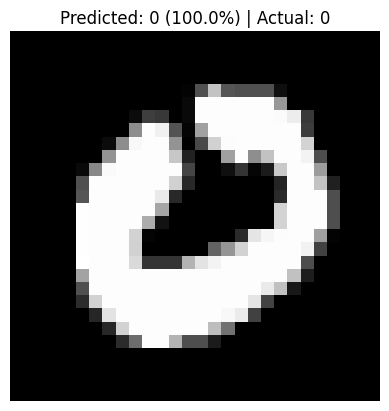

In [4]:
import numpy as np

# Pick a test image (e.g., image index 25)
test_index = 25
sample_img = x_test[test_index]
actual_label = y_test[test_index]

# Predict
prediction = model.predict(sample_img.reshape(1, 28, 28, 1))
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

# Display results
plt.imshow(sample_img.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_digit} ({confidence:.1f}%) | Actual: {actual_label}")
plt.axis('off')
plt.show()

In [5]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image
from streamlit_drawable_canvas import st_canvas

# Load saved model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("digit_model.keras")

model = load_model()

st.title("✏️ Handwritten Digit Recognizer")
st.write("Draw a single digit (0-9) inside the box below:")

# Interactive canvas
canvas_result = st_canvas(
    fill_color="black",
    stroke_width=18,
    stroke_color="white",
    background_color="black",
    height=280,
    width=280,
    drawing_mode="freedraw",
    key="canvas",
)

if st.button("Predict Digit"):
    if canvas_result.image_data is not None:
        # Convert drawn canvas image to 28x28 grayscale format
        img = Image.fromarray(canvas_result.image_data.astype('uint8')).convert('L')
        img = img.resize((28, 28))
        img_array = np.array(img).astype("float32") / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)

        # Make prediction
        pred = model.predict(img_array)
        digit = np.argmax(pred)
        confidence = np.max(pred) * 100

        st.success(f"**Predicted Digit:** {digit}")
        st.info(f"**Confidence:** {confidence:.2f}%")

Writing app.py


In [2]:
!pip install -q gradio

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image, ImageOps

# Load trained model
model = tf.keras.models.load_model("digit_model.keras")

def predict_digit(sketch_input):
    if sketch_input is None:
        return "Please draw a digit first!", None

    # 1. Extract raw image array safely from Gradio Sketchpad payload
    if isinstance(sketch_input, dict):
        # Gradio v4+ structure: composite or background layer
        if "composite" in sketch_input and sketch_input["composite"] is not None:
            img_data = sketch_input["composite"]
        elif "layers" in sketch_input and len(sketch_input["layers"]) > 0:
            img_data = sketch_input["layers"][0]
        else:
            img_data = sketch_input.get("background")
    else:
        img_data = sketch_input

    if img_data is None:
        return "Please draw a digit first!", None

    # 2. Convert array to PIL Image
    pil_img = Image.fromarray(img_data.astype('uint8'))

    # If image has Alpha channel (RGBA), paste onto pure white background first
    if pil_img.mode == 'RGBA':
        background = Image.new("RGB", pil_img.size, (255, 255, 255))
        background.paste(pil_img, mask=pil_img.split()[3]) # 3 is alpha
        pil_img = background.convert('L')
    else:
        pil_img = pil_img.convert('L')

    # 3. Invert colors so strokes become WHITE and background becomes BLACK (MNIST standard)
    img_np = np.array(pil_img)
    if np.mean(img_np) > 127: # If background is mostly white
        pil_img = ImageOps.invert(pil_img)

    # 4. Resize to 28x28 grayscale image
    pil_28x28 = pil_img.resize((28, 28), Image.Resampling.LANCZOS)

    # 5. Normalize array to [0.0, 1.0] for the neural network
    img_array = np.array(pil_28x28).astype("float32") / 255.0
    img_input = img_array.reshape(1, 28, 28, 1)

    # 6. Make prediction
    prediction = model.predict(img_input)
    predicted_digit = int(np.argmax(prediction))
    confidence = float(np.max(prediction) * 100)

    result_text = f"Predicted Digit: {predicted_digit}\nConfidence: {confidence:.2f}%"

    # Return both text result AND the 28x28 preprocessed image for visual debugging
    return result_text, pil_28x28

# Create Gradio interface with dual output (Text + Image)
interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(label="Draw a Digit (0-9) Here"),
    outputs=[
        gr.Textbox(label="Model Output"),
        gr.Image(label="Processed 28x28 Image (What the AI Sees)", image_mode="L")
    ],
    title="✏️ Handwritten Digit Recognizer",
    description="Draw a digit, then check the 'Processed 28x28 Image' box to see what the model receives."
)

interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7a9bca5189f3d84bde.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
